# EDA 7.3: Promotion Effect vs Revenue, Quantity, Discount, and Gross Margin

This notebook performs observational EDA on the relationship between promotion status and commercial outcomes. It avoids causal claims: promo periods or promo item lines may be associated with different revenue, quantity, or margin because of promotion design, seasonality, campaign targeting, traffic, product mix, stock availability, and other confounders.

## 1. Setup and File Discovery

Find required and optional CSV files anywhere under the current working directory. Missing required files are warned about and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ['order_items.csv', 'promotions.csv', 'products.csv']
OPTIONAL_FILES = ['orders.csv', 'sales.csv', 'payments.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in REQUIRED_FILES + OPTIONAL_FILES}

file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED_FILES, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

missing_required = [name for name in REQUIRED_FILES if selected_paths.get(name) is None]
for name in missing_required:
    warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
1,promotions.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
2,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
5,payments.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...


## 2. Load Order Items, Promotions, Products, and Optional Files

Load each available file with pandas. Loading is wrapped so a damaged or unavailable file produces a clear warning rather than stopping the notebook.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        warnings.warn(f'{name} not found; skipping load.')
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

raw = {name: safe_read_csv(path, name) for name, path in selected_paths.items()}
order_items = raw.get('order_items.csv')
promotions = raw.get('promotions.csv')
products = raw.get('products.csv')
orders = raw.get('orders.csv')
sales = raw.get('sales.csv')
payments = raw.get('payments.csv')

schema_rows = []
for name, df in raw.items():
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded order_items.csv: 714,669 rows x 7 columns from D:\Code\Datathon 2026\datathon-2026-round-1\order_items.csv
Loaded promotions.csv: 50 rows x 10 columns from D:\Code\Datathon 2026\datathon-2026-round-1\promotions.csv
Loaded products.csv: 2,412 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\products.csv


Loaded orders.csv: 646,945 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\orders.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


Loaded payments.csv: 646,945 rows x 4 columns from D:\Code\Datathon 2026\datathon-2026-round-1\payments.csv


,file,rows,columns,column_names
0,order_items.csv,714669,7,"order_id, product_id, quantity, unit_price, di..."
1,promotions.csv,50,10,"promo_id, promo_name, promo_type, discount_val..."
2,products.csv,2412,8,"product_id, product_name, category, segment, s..."
3,orders.csv,646945,8,"order_id, order_date, customer_id, zip, order_..."
4,sales.csv,3833,3,"Date, Revenue, COGS"
5,payments.csv,646945,4,"order_id, payment_method, payment_value, insta..."


## 3. Identify Key, Promo, Date, Category, Segment, Revenue, Quantity, Discount, and Margin Columns

Column names are matched after normalizing case, spaces, punctuation, and underscores. The helper also uses keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def find_cols(df, candidates=None, include_any=None, exclude_any=None):
    if df is None:
        return []
    candidates = candidates or []
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    out = []
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup and lookup[key] not in out:
            out.append(lookup[key])
    for col in df.columns:
        key = normalize_name(col)
        if col in out:
            continue
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_any and any(x in key for x in include_any):
            out.append(col)
    return out

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def clean_id_series(s):
    if s is None:
        return None
    out = s.astype('string').str.strip()
    return out.mask(out.isna() | out.str.lower().isin(['', 'nan', 'none', 'null', 'nat']))

cols = {}
if order_items is not None:
    cols['item_order_id'] = find_col(order_items, ['order_id', 'orderid', 'id_order'], include_all=['order', 'id'])
    cols['item_product_id'] = find_col(order_items, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['item_date'] = find_col(order_items, ['order_date', 'item_date', 'date', 'created_at'], include_any=['date', 'created'])
    cols['item_quantity'] = find_col(order_items, ['quantity', 'qty', 'units', 'units_sold'], include_any=['quantity', 'qty', 'unitssold', 'units'], exclude_any=['price', 'cost'])
    cols['item_unit_price'] = find_col(order_items, ['unit_price', 'selling_price', 'price', 'sale_price'], include_any=['unitprice', 'sellingprice', 'saleprice', 'price'], exclude_any=['discount', 'cost', 'cogs'], prefer_numeric=True)
    cols['item_revenue'] = find_col(order_items, ['revenue', 'sales_amount', 'item_total', 'line_total', 'net_sales'], include_any=['revenue', 'salesamount', 'itemtotal', 'linetotal', 'netsales'], exclude_any=['discount', 'tax', 'cost', 'cogs', 'payment'], prefer_numeric=True)
    cols['item_discount_amount'] = find_col(order_items, ['discount_amount', 'discount_value', 'discount', 'coupon_amount'], include_any=['discountamount', 'discountvalue', 'discount', 'couponamount'], exclude_any=['rate', 'percent', 'pct', 'id'], prefer_numeric=True)
    cols['item_discount_rate'] = find_col(order_items, ['discount_rate', 'discount_pct', 'discount_percent', 'discount_percentage'], include_any=['discountrate', 'discountpct', 'discountpercent', 'percentage'], exclude_any=['id'], prefer_numeric=True)
    cols['item_cost'] = find_col(order_items, ['cogs', 'cost', 'unit_cost', 'item_cost'], include_any=['cogs', 'cost'], exclude_any=['customer'], prefer_numeric=True)
    cols['item_gross_profit'] = find_col(order_items, ['gross_profit', 'grossprofit'], include_all=['gross', 'profit'], prefer_numeric=True)
    cols['item_gross_margin'] = find_col(order_items, ['gross_margin', 'gross_margin_ratio', 'margin'], include_any=['grossmargin', 'margin'], exclude_any=['profit'], prefer_numeric=True)
    cols['item_promo_candidates'] = find_cols(order_items, ['promo_id', 'promotion_id', 'campaign_id', 'coupon_id', 'discount_id'], include_any=['promoid', 'promotionid', 'campaignid', 'couponid', 'discountid'])
    cols['item_promo_flag'] = find_col(order_items, ['promo_flag', 'promotion_flag', 'is_promo', 'is_promotional'], include_any=['promoflag', 'promotionflag', 'ispromo', 'promotional'])
if products is not None:
    cols['product_product_id'] = find_col(products, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['product_category'] = find_col(products, ['category', 'product_category', 'apparel_category'], include_any=['category'])
    cols['product_segment'] = find_col(products, ['segment', 'product_segment'], include_any=['segment'])
    cols['product_cost'] = find_col(products, ['cogs', 'cost', 'unit_cost', 'standard_cost'], include_any=['cogs', 'cost'], exclude_any=['customer'], prefer_numeric=True)
    cols['product_price'] = find_col(products, ['price', 'unit_price', 'list_price'], include_any=['price'], exclude_any=['discount', 'cost'], prefer_numeric=True)
if orders is not None:
    cols['orders_order_id'] = find_col(orders, ['order_id', 'orderid', 'id_order'], include_all=['order', 'id'])
    cols['orders_date'] = find_col(orders, ['order_date', 'date', 'created_at', 'purchase_date'], include_any=['orderdate', 'date', 'created', 'purchase'])
if promotions is not None:
    cols['promo_promo_id'] = find_col(promotions, ['promo_id', 'promotion_id', 'campaign_id', 'coupon_id', 'discount_id'], include_any=['promoid', 'promotionid', 'campaignid', 'couponid', 'discountid'])
    cols['promo_type'] = find_col(promotions, ['promo_type', 'promotion_type', 'discount_type', 'type'], include_any=['promotype', 'promotiontype', 'discounttype', 'type'])
    cols['promo_start'] = find_col(promotions, ['start_date', 'promo_start_date', 'promotion_start_date'], include_any=['startdate', 'start'])
    cols['promo_end'] = find_col(promotions, ['end_date', 'promo_end_date', 'promotion_end_date'], include_any=['enddate', 'end'])
    cols['promo_discount_value'] = find_col(promotions, ['discount_value', 'discount_amount', 'discount_rate', 'discount'], include_any=['discountvalue', 'discountamount', 'discountrate', 'discount'], exclude_any=['id'], prefer_numeric=True)
    cols['promo_category'] = find_col(promotions, ['applicable_category', 'category'], include_any=['category'])

identified_columns = pd.DataFrame([{'role': k, 'column': v if not isinstance(v, list) else ', '.join(map(str, v))} for k, v in cols.items()])
display(identified_columns)

,role,column
0,item_order_id,order_id
1,item_product_id,product_id
2,item_date,None
3,item_quantity,quantity
4,item_unit_price,unit_price
5,item_revenue,None
6,item_discount_amount,discount_amount
7,item_discount_rate,None
8,item_cost,None
9,item_gross_profit,None


## 4. Build Item-Level Promo Effect Dataset

Start from `order_items`, join product attributes, optionally join order date, and optionally join promotion metadata. Revenue and margin are inferred when direct fields are missing and enough source fields exist.

In [4]:
analysis_warnings = []
join_quality = []
item = pd.DataFrame()

if order_items is None or order_items.empty:
    analysis_warnings.append('order_items.csv is missing or empty; item-level promo analysis cannot be built.')
else:
    item = order_items.copy()
    item['_row_id'] = np.arange(len(item))
    date_col = cols.get('item_date')
    if date_col is not None:
        item['date'] = pd.to_datetime(item[date_col], errors='coerce')
    elif orders is not None and cols.get('item_order_id') and cols.get('orders_order_id') and cols.get('orders_date'):
        before = len(item)
        order_date_map = orders[[cols['orders_order_id'], cols['orders_date']]].drop_duplicates(cols['orders_order_id'])
        item = item.merge(order_date_map, how='left', left_on=cols['item_order_id'], right_on=cols['orders_order_id'], suffixes=('', '_order'))
        item['date'] = pd.to_datetime(item[cols['orders_date']], errors='coerce')
        matched = item['date'].notna().sum()
        join_quality.append({'check': 'rows matched to orders for date', 'count': int(matched)})
        join_quality.append({'check': 'rows unmatched to orders/date missing after order join', 'count': int(before - matched)})
    else:
        item['date'] = pd.NaT
        analysis_warnings.append('Could not identify an item date or joinable order date.')
    item['date'] = item['date'].dt.floor('D')

    if products is not None and cols.get('item_product_id') and cols.get('product_product_id'):
        product_cols = [cols['product_product_id']]
        for role in ['product_category', 'product_segment', 'product_cost', 'product_price']:
            if cols.get(role) and cols[role] not in product_cols:
                product_cols.append(cols[role])
        prod_unique = products[product_cols].drop_duplicates(cols['product_product_id'])
        before = len(item)
        item = item.merge(prod_unique, how='left', left_on=cols['item_product_id'], right_on=cols['product_product_id'], suffixes=('', '_product'))
        product_match = item[cols['product_product_id']].notna().sum()
        join_quality.append({'check': 'order_items rows matched to products', 'count': int(product_match)})
        join_quality.append({'check': 'order_items rows unmatched to products', 'count': int(before - product_match)})
    else:
        analysis_warnings.append('Could not join products because product file/key is missing.')

    promo_candidates = cols.get('item_promo_candidates') or []
    if promo_candidates:
        promo_frame = pd.DataFrame({c: clean_id_series(item[c]) for c in promo_candidates if c in item.columns})
        item['promo_id_detected'] = promo_frame.bfill(axis=1).iloc[:, 0] if not promo_frame.empty else pd.NA
    else:
        item['promo_id_detected'] = pd.NA
        analysis_warnings.append('No explicit promo/campaign/coupon/discount ID column found in order_items.')

    item['quantity'] = to_num(item[cols['item_quantity']]) if cols.get('item_quantity') else np.nan
    item['unit_price'] = to_num(item[cols['item_unit_price']]) if cols.get('item_unit_price') else np.nan
    item['discount_amount'] = to_num(item[cols['item_discount_amount']]) if cols.get('item_discount_amount') else 0.0
    item['discount_rate'] = to_num(item[cols['item_discount_rate']]) if cols.get('item_discount_rate') else np.nan
    item['discount_amount'] = item['discount_amount'].fillna(0)

    if cols.get('item_revenue'):
        item['revenue'] = to_num(item[cols['item_revenue']])
        revenue_source = f'direct column: {cols["item_revenue"]}'
    elif cols.get('item_unit_price') and cols.get('item_quantity'):
        item['revenue'] = item['unit_price'] * item['quantity']
        revenue_source = 'inferred as unit_price * quantity (unit price is post-discount)'
    else:
        item['revenue'] = np.nan
        revenue_source = 'unavailable'
        analysis_warnings.append('Revenue could not be identified or inferred from price, quantity, and discount.')

    item['category'] = item[cols['product_category']].astype('string').fillna('Unknown') if cols.get('product_category') and cols.get('product_category') in item.columns else 'Unknown'
    if item['category'].eq('Unknown').all():
        analysis_warnings.append('Product category is unavailable; category response analysis will be limited.')
    if cols.get('product_segment') and cols.get('product_segment') in item.columns:
        item['segment'] = item[cols['product_segment']].astype('string').fillna('Unknown')
    else:
        item['segment'] = pd.NA
        analysis_warnings.append('Product segment is unavailable; segment response analysis will be skipped.')

    cost_source = None
    if cols.get('item_cost'):
        raw_cost = to_num(item[cols['item_cost']])
        cost_source = f'order_items column: {cols["item_cost"]}'
    elif cols.get('product_cost') and cols.get('product_cost') in item.columns:
        raw_cost = to_num(item[cols['product_cost']])
        cost_source = f'products column: {cols["product_cost"]}'
    else:
        raw_cost = pd.Series(np.nan, index=item.index)
    if raw_cost.notna().any():
        item['unit_cogs'] = raw_cost
        item['cogs'] = item['unit_cogs'] * item['quantity']
    else:
        item['unit_cogs'] = np.nan
        item['cogs'] = np.nan
        analysis_warnings.append('COGS/cost not found; gross margin cannot be fully evaluated.')

    if cols.get('item_gross_profit'):
        item['gross_profit'] = to_num(item[cols['item_gross_profit']])
        gross_profit_source = f'direct column: {cols["item_gross_profit"]}'
    elif item['cogs'].notna().any() and item['revenue'].notna().any():
        item['gross_profit'] = item['revenue'] - item['cogs']
        gross_profit_source = 'computed as revenue - COGS'
    else:
        item['gross_profit'] = np.nan
        gross_profit_source = 'unavailable'

    if cols.get('item_gross_margin'):
        gm = to_num(item[cols['item_gross_margin']])
        item['gross_margin_ratio'] = np.where(gm.abs() > 1.5, gm / 100.0, gm)
        margin_source = f'direct column: {cols["item_gross_margin"]}'
    elif item['gross_profit'].notna().any() and item['revenue'].notna().any():
        item['gross_margin_ratio'] = item['gross_profit'] / item['revenue'].replace(0, np.nan)
        margin_source = 'computed as gross_profit / revenue'
    else:
        item['gross_margin_ratio'] = np.nan
        margin_source = 'unavailable'

    explicit_promo = item['promo_id_detected'].notna()
    if cols.get('item_promo_flag'):
        flag_values = item[cols['item_promo_flag']]
        flag_promo = to_num(flag_values).fillna(0).astype(float) > 0 if pd.api.types.is_numeric_dtype(flag_values) else flag_values.astype('string').str.strip().str.lower().isin(['1', 'true', 'yes', 'y', 'promo', 'promotional'])
    else:
        flag_promo = pd.Series(False, index=item.index)
    item['promo_used'] = (explicit_promo | (item['discount_amount'].fillna(0) > 0) | (item['discount_rate'].fillna(0) > 0) | flag_promo).fillna(False)

    if promotions is not None and cols.get('promo_promo_id') and item['promo_id_detected'].notna().any():
        promo_meta_cols = [cols['promo_promo_id']]
        for role in ['promo_type', 'promo_start', 'promo_end', 'promo_discount_value', 'promo_category']:
            if cols.get(role) and cols[role] not in promo_meta_cols:
                promo_meta_cols.append(cols[role])
        promo_meta = promotions[promo_meta_cols].drop_duplicates(cols['promo_promo_id']).copy()
        promo_meta['_promo_id_key'] = clean_id_series(promo_meta[cols['promo_promo_id']])
        item = item.merge(promo_meta.drop(columns=[cols['promo_promo_id']]), how='left', left_on='promo_id_detected', right_on='_promo_id_key', suffixes=('', '_promo'))
        has_promo_id = item['promo_id_detected'].notna()
        promo_matched = item.loc[has_promo_id, '_promo_id_key'].notna().sum() if '_promo_id_key' in item.columns else 0
        join_quality.append({'check': 'rows with promo IDs matched to promotions', 'count': int(promo_matched)})
        join_quality.append({'check': 'rows with promo IDs not found in promotions', 'count': int(has_promo_id.sum() - promo_matched)})
        join_quality.append({'check': 'rows with missing promo IDs', 'count': int(item['promo_id_detected'].isna().sum())})
    else:
        join_quality.append({'check': 'rows with missing promo IDs', 'count': int(item['promo_id_detected'].isna().sum())})
        if promotions is None:
            analysis_warnings.append('promotions.csv is unavailable; promotion metadata cannot be joined.')
        elif not cols.get('promo_promo_id'):
            analysis_warnings.append('Promotion ID column not found in promotions.csv; promotion metadata cannot be joined.')

    promo_type_col = cols.get('promo_type') if cols.get('promo_type') in item.columns else None
    item['promo_type'] = item[promo_type_col].astype('string').fillna('Unknown') if promo_type_col else pd.NA

    keep_cols = ['_row_id', 'date', 'promo_used', 'promo_id_detected', 'promo_type', 'category', 'segment', 'quantity', 'unit_price', 'discount_amount', 'discount_rate', 'revenue', 'unit_cogs', 'cogs', 'gross_profit', 'gross_margin_ratio']
    analysis = item[[c for c in keep_cols if c in item.columns]].copy()
    analysis['promo_status'] = np.where(analysis['promo_used'], 'Promo', 'Non-promo')
    for c in ['revenue', 'quantity', 'discount_amount', 'cogs']:
        if c in analysis.columns:
            join_quality.append({'check': f'rows with missing {c}', 'count': int(analysis[c].isna().sum())})

    print('Revenue source:', revenue_source)
    print('Cost source:', cost_source or 'unavailable')
    print('Gross profit source:', gross_profit_source)
    print('Margin source:', margin_source)
    display(analysis.head())

join_quality_df = pd.DataFrame(join_quality)
display(join_quality_df)
if analysis_warnings:
    print('Analysis warnings:')
    for w in analysis_warnings:
        print('-', w)

Revenue source: inferred as unit_price * quantity (unit price is post-discount)
Cost source: products column: cogs
Gross profit source: computed as revenue - COGS
Margin source: computed as gross_profit / revenue


,_row_id,date,promo_used,promo_id_detected,promo_type,category,segment,quantity,unit_price,discount_amount,discount_rate,revenue,unit_cogs,cogs,gross_profit,gross_margin_ratio,promo_status
0,0,2012-07-04,False,<NA>,Unknown,GenZ,Trendy,7,"1,138.2200",0.0000,NaN,"7,967.5400","1,053.7980","7,376.5861",590.9539,0.0742,Non-promo
1,1,2012-07-04,False,<NA>,Unknown,Streetwear,Everyday,7,"10,166.2500",0.0000,NaN,"71,163.7500","8,987.7042","62,913.9296","8,249.8204",0.1159,Non-promo
2,2,2012-07-04,False,<NA>,Unknown,Streetwear,Balanced,3,"11,220.3300",0.0000,NaN,"33,660.9900","10,091.0123","30,273.0368","3,387.9532",0.1006,Non-promo
3,3,2012-07-04,False,<NA>,Unknown,Streetwear,Everyday,5,"10,639.2500",0.0000,NaN,"53,196.2500","9,205.4305","46,027.1524","7,169.0976",0.1348,Non-promo
4,4,2012-07-06,False,<NA>,Unknown,Outdoor,Activewear,1,"1,597.8400",0.0000,NaN,"1,597.8400","1,048.6964","1,048.6964",549.1436,0.3437,Non-promo


,check,count
0,rows matched to orders for date,714669
1,rows unmatched to orders/date missing after or...,0
2,order_items rows matched to products,714669
3,order_items rows unmatched to products,0
4,rows with promo IDs matched to promotions,276316
5,rows with promo IDs not found in promotions,0
6,rows with missing promo IDs,438353
7,rows with missing revenue,0
8,rows with missing quantity,0
9,rows with missing discount_amount,0


## 5. Join and Promotion Data Quality Checks

Check promo-key consistency, discount anomalies, revenue and quantity validity, and margin plausibility. These diagnostics help determine whether promotion fields are reliable enough for modeling or explainability.

In [5]:
quality_tables = {}
quality_warning_messages = []

if 'analysis' not in globals() or analysis.empty:
    print('No analysis dataset available for quality checks.')
else:
    if promotions is not None and cols.get('promo_promo_id') and 'promo_id_detected' in analysis.columns:
        promo_ids_items = set(analysis['promo_id_detected'].dropna().astype(str))
        promo_ids_master = set(clean_id_series(promotions[cols['promo_promo_id']]).dropna().astype(str))
        missing_in_promos = sorted(promo_ids_items - promo_ids_master)
        unused_promos = sorted(promo_ids_master - promo_ids_items)
        quality_tables['promo_ids_in_items_not_promotions'] = pd.DataFrame({'promo_id': missing_in_promos[:50]})
        quality_tables['promotions_with_no_matching_items'] = pd.DataFrame({'promo_id': unused_promos[:50]})
        if missing_in_promos:
            quality_warning_messages.append(f'{len(missing_in_promos):,} promo IDs in order_items were not found in promotions.')
        if unused_promos:
            quality_warning_messages.append(f'{len(unused_promos):,} promotions have no matching item lines.')

    if {'discount_amount', 'promo_id_detected'}.issubset(analysis.columns):
        quality_tables['discount_gt_zero_missing_promo_id'] = analysis.loc[(analysis['discount_amount'].fillna(0) > 0) & analysis['promo_id_detected'].isna(), ['date', 'category', 'quantity', 'discount_amount', 'revenue']].head(50)
        quality_tables['promo_id_zero_blank_discount'] = analysis.loc[analysis['promo_id_detected'].notna() & (analysis['discount_amount'].fillna(0) <= 0), ['date', 'promo_id_detected', 'promo_type', 'category', 'quantity', 'discount_amount', 'revenue']].head(50)
        quality_tables['negative_discounts'] = analysis.loc[analysis['discount_amount'].fillna(0) < 0, ['date', 'promo_id_detected', 'category', 'discount_amount', 'revenue']].head(50)

    if 'discount_rate' in analysis.columns and analysis['discount_rate'].notna().any():
        rate = analysis['discount_rate']
        rate_as_ratio = np.where(rate.abs() > 1.5, rate / 100.0, rate)
        quality_tables['discount_rate_above_100pct'] = analysis.loc[pd.Series(rate_as_ratio, index=analysis.index) > 1, ['date', 'promo_id_detected', 'category', 'discount_rate', 'quantity', 'revenue']].head(50)
    if 'revenue' in analysis.columns:
        quality_tables['negative_revenue'] = analysis.loc[analysis['revenue'].fillna(0) < 0, ['date', 'promo_id_detected', 'category', 'quantity', 'discount_amount', 'revenue']].head(50)
    if 'quantity' in analysis.columns:
        quality_tables['zero_or_negative_quantity'] = analysis.loc[analysis['quantity'].fillna(0) <= 0, ['date', 'promo_id_detected', 'category', 'quantity', 'discount_amount', 'revenue']].head(50)
    if 'gross_margin_ratio' in analysis.columns and analysis['gross_margin_ratio'].notna().any():
        quality_tables['impossible_margin_values'] = analysis.loc[(analysis['gross_margin_ratio'] < -1) | (analysis['gross_margin_ratio'] > 1), ['date', 'promo_id_detected', 'category', 'revenue', 'gross_profit', 'gross_margin_ratio']].head(50)

    quality_summary_rows = []
    for name, table in quality_tables.items():
        if name == 'discount_gt_zero_missing_promo_id':
            count = int(((analysis['discount_amount'].fillna(0) > 0) & analysis['promo_id_detected'].isna()).sum())
        elif name == 'promo_id_zero_blank_discount':
            count = int((analysis['promo_id_detected'].notna() & (analysis['discount_amount'].fillna(0) <= 0)).sum())
        elif name == 'negative_discounts':
            count = int((analysis['discount_amount'].fillna(0) < 0).sum())
        elif name == 'negative_revenue':
            count = int((analysis['revenue'].fillna(0) < 0).sum())
        elif name == 'zero_or_negative_quantity':
            count = int((analysis['quantity'].fillna(0) <= 0).sum())
        elif name == 'impossible_margin_values':
            count = int(((analysis['gross_margin_ratio'] < -1) | (analysis['gross_margin_ratio'] > 1)).sum())
        elif name == 'promo_ids_in_items_not_promotions':
            count = len(missing_in_promos)
        elif name == 'promotions_with_no_matching_items':
            count = len(unused_promos)
        else:
            count = len(table)
        quality_summary_rows.append({'check': name, 'count': count})
    quality_summary = pd.DataFrame(quality_summary_rows).sort_values('count', ascending=False) if quality_summary_rows else pd.DataFrame()
    display(quality_summary)

    for name, table in quality_tables.items():
        if not table.empty:
            print(f'Example records: {name}')
            display(table)
    if quality_warning_messages:
        print('Promotion data quality warnings:')
        for msg in quality_warning_messages:
            print('-', msg)

,check,count
7,impossible_margin_values,44
0,promo_ids_in_items_not_promotions,0
2,discount_gt_zero_missing_promo_id,0
1,promotions_with_no_matching_items,0
3,promo_id_zero_blank_discount,0
4,negative_discounts,0
5,negative_revenue,0
6,zero_or_negative_quantity,0


Example records: impossible_margin_values


,date,promo_id_detected,category,revenue,gross_profit,gross_margin_ratio
90831,2013-08-01,PROMO-0005,Streetwear,"5,322.0700","-5,361.0663",-1.0073
91290,2013-07-30,PROMO-0005,Streetwear,"24,320.1000","-24,512.6858",-1.0079
92626,2013-08-01,PROMO-0005,Streetwear,"19,869.3000","-20,438.8290",-1.0287
93618,2013-08-10,PROMO-0005,Streetwear,"6,713.6800","-6,722.3630",-1.0013
94127,2013-08-15,PROMO-0005,Streetwear,"9,006.9300","-9,019.8900",-1.0014
95497,2013-08-15,PROMO-0005,Streetwear,"23,373.4900","-23,652.6605",-1.0119
96355,2013-08-20,PROMO-0005,Streetwear,"42,015.6000","-42,041.0121",-1.0006
96860,2013-08-22,PROMO-0005,Streetwear,"38,306.4500","-38,445.0553",-1.0036
97413,2013-08-28,PROMO-0005,Streetwear,"5,635.5300","-5,656.6213",-1.0037
98529,2013-08-29,PROMO-0005,Streetwear,"24,091.9200","-24,283.6206",-1.0080


## 6. Promo vs Non-Promo Summary

Compare item lines by promo status. These results are descriptive: promo lines may differ because campaigns target certain products, days, customers, or traffic periods.

In [6]:
def weighted_margin(df):
    if df is None or df.empty or 'gross_profit' not in df or 'revenue' not in df:
        return np.nan
    denom = df['revenue'].sum(skipna=True)
    return np.nan if pd.isna(denom) or denom == 0 else df['gross_profit'].sum(skipna=True) / denom

if 'analysis' not in globals() or analysis.empty:
    print('No analysis dataset available for promo summary.')
elif 'promo_used' not in analysis or 'revenue' not in analysis or 'quantity' not in analysis:
    print('Promotion status, revenue, or quantity could not be identified; promo summary cannot be computed.')
else:
    summary = analysis.groupby('promo_status', dropna=False).agg(
        total_item_lines=('_row_id', 'count'),
        total_quantity_sold=('quantity', 'sum'),
        total_revenue=('revenue', 'sum'),
        average_item_revenue=('revenue', 'mean'),
        median_item_revenue=('revenue', 'median'),
        average_quantity_per_line=('quantity', 'mean'),
        average_discount_amount=('discount_amount', 'mean'),
        gross_profit=('gross_profit', 'sum'),
    ).reset_index()
    if 'discount_rate' in analysis.columns and analysis['discount_rate'].notna().any():
        summary = summary.merge(analysis.groupby('promo_status')['discount_rate'].mean().rename('average_discount_rate').reset_index(), on='promo_status', how='left')
    if 'gross_margin_ratio' in analysis.columns and analysis['gross_margin_ratio'].notna().any():
        gm = analysis.groupby('promo_status').apply(weighted_margin).rename('gross_margin_ratio').reset_index()
        summary = summary.merge(gm, on='promo_status', how='left')
    display(summary)

C:\Users\ACER\AppData\Local\Temp\ipykernel_9000\592399984.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gm = analysis.groupby('promo_status').apply(weighted_margin).rename('gross_margin_ratio').reset_index()


,promo_status,total_item_lines,total_quantity_sold,total_revenue,average_item_revenue,median_item_revenue,average_quantity_per_line,average_discount_amount,gross_profit,gross_margin_ratio
0,Non-promo,438353,1971104,"10,995,039,052.9000","25,082.6139","17,304.5100",4.4966,0.0000,"2,195,015,385.5755",0.1996
1,Promo,276316,1242039,"5,435,437,532.6300","19,671.0923","12,818.7400",4.4950,"2,712.8625","72,010,680.8267",0.0132


## 7. Daily Promo vs Non-Promo Revenue Analysis

Aggregate item lines to daily revenue and quantity, then compare days with any promo activity against days without observed promo activity.

,date,nonpromo_revenue,promo_revenue,nonpromo_quantity,promo_quantity,nonpromo_lines,promo_lines,nonpromo_gross_profit,promo_gross_profit,total_revenue,total_quantity,total_lines,promo_revenue_share,promo_quantity_share,promo_line_ratio,promo_active_day,gross_margin_ratio,promo_gross_margin_ratio,nonpromo_gross_margin_ratio
0,2012-07-04,"5,123,547.9400",0.0000,777.0000,0.0000,174.0000,0.0000,"1,140,556.7506",0.0000,"5,123,547.9400",777.0000,174.0000,0.0000,0.0000,0.0000,False,0.2226,NaN,0.2226
1,2012-07-05,"2,751,773.4500",0.0000,428.0000,0.0000,103.0000,0.0000,"601,193.2162",0.0000,"2,751,773.4500",428.0000,103.0000,0.0000,0.0000,0.0000,False,0.2185,NaN,0.2185
2,2012-07-06,"3,054,029.4200",0.0000,441.0000,0.0000,99.0000,0.0000,"536,396.5766",0.0000,"3,054,029.4200",441.0000,99.0000,0.0000,0.0000,0.0000,False,0.1756,NaN,0.1756
3,2012-07-07,"2,667,930.9400",0.0000,364.0000,0.0000,75.0000,0.0000,"559,684.3194",0.0000,"2,667,930.9400",364.0000,75.0000,0.0000,0.0000,0.0000,False,0.2098,NaN,0.2098
4,2012-07-08,"2,360,851.9000",0.0000,394.0000,0.0000,94.0000,0.0000,"552,229.1051",0.0000,"2,360,851.9000",394.0000,94.0000,0.0000,0.0000,0.0000,False,0.2339,NaN,0.2339


,promo_active_day,days,average_daily_revenue,median_daily_revenue,average_daily_quantity,median_daily_quantity,average_promo_revenue_share,average_gross_margin_ratio
0,False,2126,"4,524,082.5063","3,819,856.3500",806.3062,660.5000,0.0000,0.1984
1,True,1707,"3,990,789.2074","3,428,606.6400",878.1113,743.0000,0.8114,0.0345


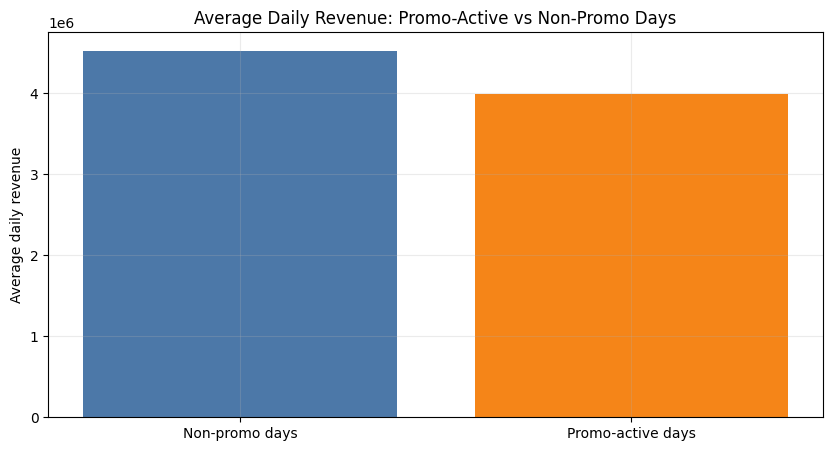

In [7]:
daily = pd.DataFrame()
if 'analysis' not in globals() or analysis.empty or analysis['date'].isna().all():
    print('Date is unavailable; daily promo vs non-promo analysis cannot be computed.')
else:
    base = analysis.dropna(subset=['date']).copy()
    by_day_status = base.groupby(['date', 'promo_status']).agg(
        revenue=('revenue', 'sum'),
        quantity=('quantity', 'sum'),
        lines=('_row_id', 'count'),
        gross_profit=('gross_profit', 'sum'),
        discount_amount=('discount_amount', 'mean'),
    ).reset_index()
    pivot = by_day_status.pivot(index='date', columns='promo_status', values=['revenue', 'quantity', 'lines', 'gross_profit']).fillna(0)
    pivot.columns = [f'{str(status).lower().replace("-", "")}_{metric}' for metric, status in pivot.columns]
    daily = pivot.reset_index()
    for col in ['promo_revenue', 'nonpromo_revenue', 'promo_quantity', 'nonpromo_quantity', 'promo_lines', 'nonpromo_lines', 'promo_gross_profit', 'nonpromo_gross_profit']:
        if col not in daily.columns:
            daily[col] = 0.0
    daily['total_revenue'] = daily['promo_revenue'] + daily['nonpromo_revenue']
    daily['total_quantity'] = daily['promo_quantity'] + daily['nonpromo_quantity']
    daily['total_lines'] = daily['promo_lines'] + daily['nonpromo_lines']
    daily['promo_revenue_share'] = daily['promo_revenue'] / daily['total_revenue'].replace(0, np.nan)
    daily['promo_quantity_share'] = daily['promo_quantity'] / daily['total_quantity'].replace(0, np.nan)
    daily['promo_line_ratio'] = daily['promo_lines'] / daily['total_lines'].replace(0, np.nan)
    daily['promo_active_day'] = daily['promo_lines'] > 0
    if analysis['gross_margin_ratio'].notna().any():
        daily['gross_margin_ratio'] = (daily['promo_gross_profit'] + daily['nonpromo_gross_profit']) / daily['total_revenue'].replace(0, np.nan)
        daily['promo_gross_margin_ratio'] = daily['promo_gross_profit'] / daily['promo_revenue'].replace(0, np.nan)
        daily['nonpromo_gross_margin_ratio'] = daily['nonpromo_gross_profit'] / daily['nonpromo_revenue'].replace(0, np.nan)

    daily_compare = daily.groupby('promo_active_day').agg(
        days=('date', 'count'),
        average_daily_revenue=('total_revenue', 'mean'),
        median_daily_revenue=('total_revenue', 'median'),
        average_daily_quantity=('total_quantity', 'mean'),
        median_daily_quantity=('total_quantity', 'median'),
        average_promo_revenue_share=('promo_revenue_share', 'mean'),
    ).reset_index()
    if 'gross_margin_ratio' in daily.columns:
        daily_compare = daily_compare.merge(daily.groupby('promo_active_day')['gross_margin_ratio'].mean().rename('average_gross_margin_ratio').reset_index(), on='promo_active_day', how='left')
    display(daily.head())
    display(daily_compare)

    fig, ax = plt.subplots()
    chart_data = daily_compare.assign(day_type=np.where(daily_compare['promo_active_day'], 'Promo-active days', 'Non-promo days'))
    ax.bar(chart_data['day_type'], chart_data['average_daily_revenue'], color=['#4C78A8', '#F58518'])
    ax.set_title('Average Daily Revenue: Promo-Active vs Non-Promo Days')
    ax.set_ylabel('Average daily revenue')
    plt.xticks(rotation=0)
    plt.show()

## 8. Quantity Sold Promo vs Non-Promo

Compare quantity sold by item-line promo status and by promo-active day status. Also inspect average revenue per unit and margin where available.

,promo_status,lines,total_quantity,average_quantity_per_line,median_quantity_per_line,total_revenue,total_gross_profit,average_revenue_per_unit,gross_margin_ratio
0,Non-promo,438353,1971104,4.4966,4.0000,"10,995,039,052.9000","2,195,015,385.5755","5,578.1121",0.1996
1,Promo,276316,1242039,4.4950,5.0000,"5,435,437,532.6300","72,010,680.8267","4,376.2213",0.0132


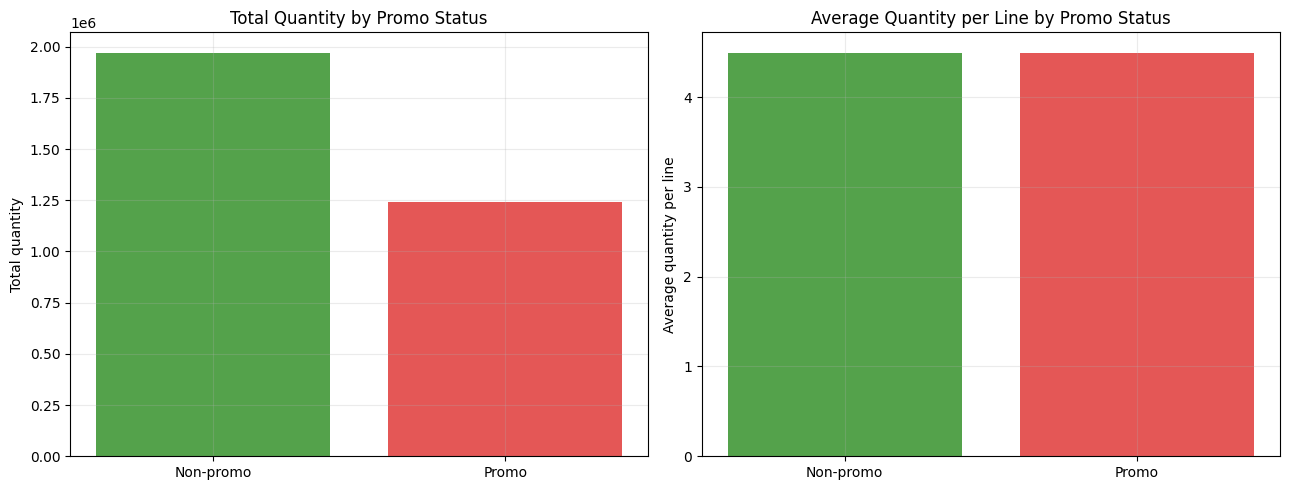

,promo_active_day,days,average_daily_quantity,median_daily_quantity,total_revenue,total_quantity,average_revenue_per_unit
0,False,2126,806.3062,660.5000,"9,618,199,408.4800","1,714,207.0000","5,610.8740"
1,True,1707,878.1113,743.0000,"6,812,277,177.0500","1,498,936.0000","4,544.7419"


In [8]:
if 'analysis' not in globals() or analysis.empty or 'quantity' not in analysis:
    print('Quantity is unavailable; quantity analysis cannot be computed.')
else:
    qty_line = analysis.groupby('promo_status').agg(
        lines=('_row_id', 'count'),
        total_quantity=('quantity', 'sum'),
        average_quantity_per_line=('quantity', 'mean'),
        median_quantity_per_line=('quantity', 'median'),
        total_revenue=('revenue', 'sum'),
        total_gross_profit=('gross_profit', 'sum'),
    ).reset_index()
    qty_line['average_revenue_per_unit'] = qty_line['total_revenue'] / qty_line['total_quantity'].replace(0, np.nan)
    if analysis['gross_margin_ratio'].notna().any():
        qty_line['gross_margin_ratio'] = qty_line['total_gross_profit'] / qty_line['total_revenue'].replace(0, np.nan)
    display(qty_line)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(qty_line['promo_status'], qty_line['total_quantity'], color=['#54A24B', '#E45756'])
    axes[0].set_title('Total Quantity by Promo Status')
    axes[0].set_ylabel('Total quantity')
    axes[1].bar(qty_line['promo_status'], qty_line['average_quantity_per_line'], color=['#54A24B', '#E45756'])
    axes[1].set_title('Average Quantity per Line by Promo Status')
    axes[1].set_ylabel('Average quantity per line')
    plt.tight_layout()
    plt.show()

    if not daily.empty:
        qty_day = daily.groupby('promo_active_day').agg(
            days=('date', 'count'),
            average_daily_quantity=('total_quantity', 'mean'),
            median_daily_quantity=('total_quantity', 'median'),
            total_revenue=('total_revenue', 'sum'),
            total_quantity=('total_quantity', 'sum'),
        ).reset_index()
        qty_day['average_revenue_per_unit'] = qty_day['total_revenue'] / qty_day['total_quantity'].replace(0, np.nan)
        display(qty_day)

## 9. Discount Amount vs Quantity Analysis

Inspect the association between discount intensity and quantity. Correlations and bins are descriptive and should not be interpreted as promotion effects without stronger identification.

Correlation between discount_amount and quantity: 0.2322


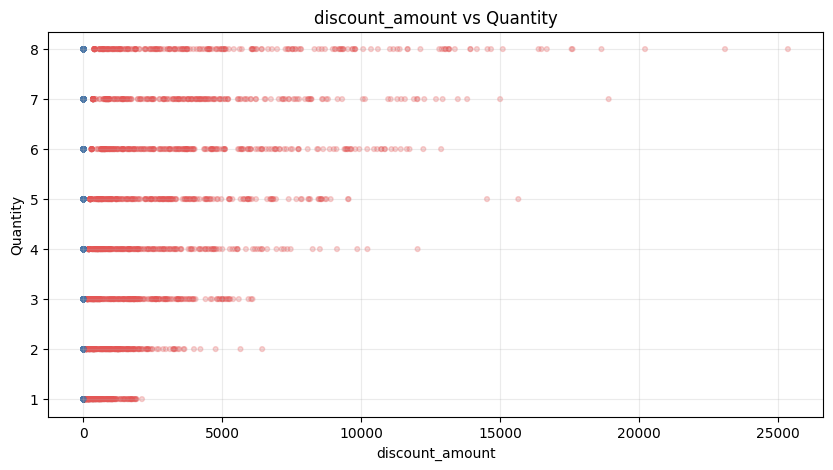

,discount_bin,lines,min_discount,max_discount,avg_quantity,total_quantity,avg_revenue,total_revenue,avg_margin
0,"(0.999, 142934.6]",142934,0.0000,0.0000,4.4954,642542,"21,523.4270","3,076,429,514.5300",0.2105
1,"(142934.6, 285868.2]",142934,0.0000,0.0000,4.5006,643284,"24,752.9042","3,538,031,602.3600",0.2093
2,"(285868.2, 428801.8]",142933,0.0000,0.0000,4.4926,642142,"28,409.5566","4,060,663,159.6200",0.2066
3,"(428801.8, 571735.4]",142934,0.0000,"1,527.2500",3.6183,517173,"9,032.0197","1,290,982,698.7300",-0.0144
4,"(571735.4, 714669.0]",142934,"1,527.2900","35,235.4700",5.3731,768002,"31,233.7835","4,464,369,610.2900",0.0568


In [9]:
if 'analysis' not in globals() or analysis.empty or 'quantity' not in analysis:
    print('Quantity is unavailable; discount analysis cannot be computed.')
else:
    discount_field = None
    if 'discount_rate' in analysis.columns and analysis['discount_rate'].notna().any() and analysis['discount_rate'].abs().sum() > 0:
        discount_field = 'discount_rate'
    elif 'discount_amount' in analysis.columns and analysis['discount_amount'].notna().any():
        discount_field = 'discount_amount'

    if discount_field is None:
        print('No usable discount amount or discount rate was found.')
    else:
        disc = analysis[[discount_field, 'quantity', 'revenue', 'gross_margin_ratio', 'promo_status']].copy()
        disc = disc.replace([np.inf, -np.inf], np.nan).dropna(subset=[discount_field, 'quantity'])
        if disc.empty:
            print('Discount and quantity have no overlapping valid records.')
        else:
            sample = disc.sample(min(len(disc), 5000), random_state=23) if len(disc) > 5000 else disc
            corr = disc[[discount_field, 'quantity']].corr().iloc[0, 1]
            print(f'Correlation between {discount_field} and quantity: {corr:,.4f}')
            fig, ax = plt.subplots()
            ax.scatter(sample[discount_field], sample['quantity'], alpha=0.25, s=12, c=np.where(sample['promo_status'].eq('Promo'), '#E45756', '#4C78A8'))
            ax.set_title(f'{discount_field} vs Quantity')
            ax.set_xlabel(discount_field)
            ax.set_ylabel('Quantity')
            plt.show()

            unique_vals = disc[discount_field].nunique(dropna=True)
            if unique_vals > 1:
                try:
                    disc['discount_bin'] = pd.qcut(disc[discount_field].rank(method='first'), q=min(5, unique_vals), duplicates='drop')
                except Exception:
                    disc['discount_bin'] = pd.cut(disc[discount_field], bins=min(5, unique_vals), duplicates='drop')
                bin_summary = disc.groupby('discount_bin', observed=False).agg(
                    lines=('quantity', 'count'),
                    min_discount=(discount_field, 'min'),
                    max_discount=(discount_field, 'max'),
                    avg_quantity=('quantity', 'mean'),
                    total_quantity=('quantity', 'sum'),
                    avg_revenue=('revenue', 'mean'),
                    total_revenue=('revenue', 'sum'),
                    avg_margin=('gross_margin_ratio', 'mean'),
                ).reset_index()
                display(bin_summary)

            extreme_discount = analysis.loc[(analysis.get('discount_amount', pd.Series(0, index=analysis.index)).abs() > analysis['revenue'].abs().quantile(0.99)) | (analysis.get('discount_amount', pd.Series(0, index=analysis.index)) < 0), ['date', 'promo_id_detected', 'category', 'quantity', 'discount_amount', 'revenue']].head(50)
            if not extreme_discount.empty:
                print('Potential extreme or suspicious discount records:')
                display(extreme_discount)

## 10. Gross Margin by Promo Status

If COGS, gross profit, or gross margin is available, compare promo and non-promo margin behavior. Otherwise this section states the limitation clearly.

,promo_status,lines,total_revenue,gross_profit,avg_line_gross_margin,median_line_gross_margin,weighted_gross_margin_ratio
0,Non-promo,438353,"10,995,039,052.9000","2,195,015,385.5755",0.2083,0.1815,0.1996
1,Promo,276316,"5,435,437,532.6300","72,010,680.8267",0.0155,0.0138,0.0132


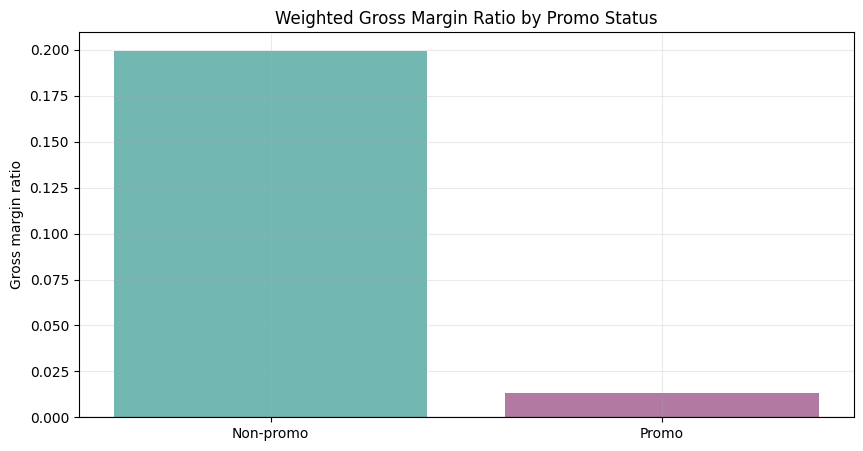

,promo_type,lines,revenue,quantity,avg_discount,gross_profit,gross_margin_ratio
1,percentage,255366,"5,058,963,791.3300",1147508,"2,916.9144","302,541,422.1555",0.0598
0,fixed,20950,"376,473,741.3000",94531,225.6110,"-230,530,741.3288",-0.6123


In [10]:
margin_available = 'analysis' in globals() and not analysis.empty and 'gross_margin_ratio' in analysis.columns and analysis['gross_margin_ratio'].notna().any()
if not margin_available:
    print('Gross margin cannot be evaluated because COGS/cost/gross profit/gross margin data is unavailable or entirely missing.')
else:
    margin_summary = analysis.groupby('promo_status').agg(
        lines=('_row_id', 'count'),
        total_revenue=('revenue', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        avg_line_gross_margin=('gross_margin_ratio', 'mean'),
        median_line_gross_margin=('gross_margin_ratio', 'median'),
    ).reset_index()
    margin_summary['weighted_gross_margin_ratio'] = margin_summary['gross_profit'] / margin_summary['total_revenue'].replace(0, np.nan)
    display(margin_summary)

    fig, ax = plt.subplots()
    ax.bar(margin_summary['promo_status'], margin_summary['weighted_gross_margin_ratio'], color=['#72B7B2', '#B279A2'])
    ax.set_title('Weighted Gross Margin Ratio by Promo Status')
    ax.set_ylabel('Gross margin ratio')
    ax.axhline(0, color='black', linewidth=0.8)
    plt.show()

    if 'promo_type' in analysis.columns and analysis['promo_type'].notna().any():
        promo_margin_type = analysis.loc[analysis['promo_used']].groupby('promo_type').agg(
            lines=('_row_id', 'count'),
            revenue=('revenue', 'sum'),
            quantity=('quantity', 'sum'),
            avg_discount=('discount_amount', 'mean'),
            gross_profit=('gross_profit', 'sum'),
        ).reset_index()
        promo_margin_type['gross_margin_ratio'] = promo_margin_type['gross_profit'] / promo_margin_type['revenue'].replace(0, np.nan)
        display(promo_margin_type.sort_values('revenue', ascending=False))

## 11. Category Response to Promotions

For each category, compare promo vs non-promo quantity, revenue, usage rate, and margin if available. Lift columns are observational proxies: average promo-line metric divided by average non-promo-line metric.

,category,promo_lines,nonpromo_lines,promo_usage_rate,promo_quantity,nonpromo_quantity,promo_revenue,nonpromo_revenue,promo_revenue_share,quantity_lift_proxy,revenue_lift_proxy,small_sample_flag,promo_gross_margin_ratio,nonpromo_gross_margin_ratio,margin_gap_promo_minus_nonpromo
2,Outdoor,108341,151645,0.4167,488306,681694,"905,670,857.1100","1,589,211,897.0900",0.3630,1.0026,0.7977,False,0.0727,0.2156,-0.1429
3,Streetwear,147668,245865,0.3752,663232,1105594,"4,290,286,430.2500","8,841,059,922.3700",0.3267,0.9988,0.8080,False,-0.0013,0.1973,-0.1987
0,Casual,8075,15916,0.3366,35990,71479,"138,691,520.1000","321,956,863.2500",0.3011,0.9924,0.8491,False,0.0145,0.1618,-0.1473
1,GenZ,12232,24927,0.3292,54511,112337,"100,788,725.1700","242,810,370.1900",0.2933,0.9889,0.8459,False,0.0987,0.2297,-0.1310


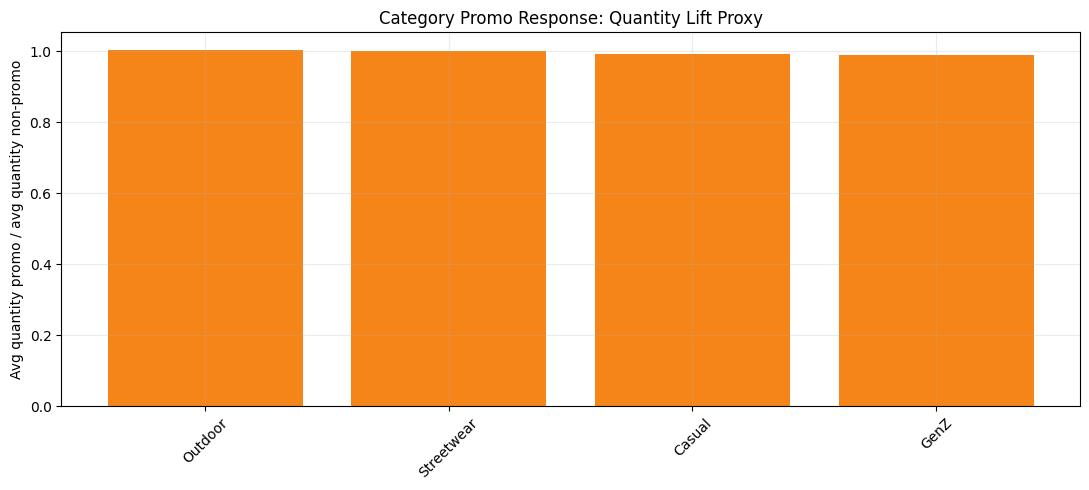

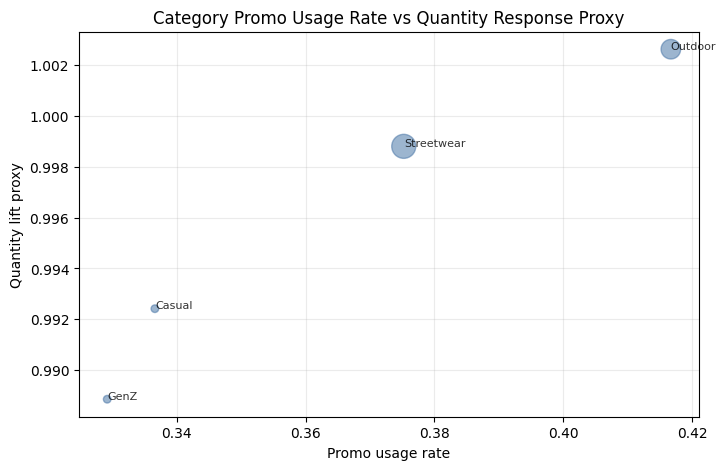

Categories with higher promo-associated quantity but weaker promo margin:


,category,quantity_lift_proxy,promo_gross_margin_ratio,nonpromo_gross_margin_ratio,margin_gap_promo_minus_nonpromo,promo_revenue,promo_quantity
2,Outdoor,1.0026,0.0727,0.2156,-0.1429,"905,670,857.1100",488306


In [11]:
category_response = pd.DataFrame()
if 'analysis' not in globals() or analysis.empty or 'category' not in analysis.columns:
    print('Category is unavailable; category response analysis cannot be computed.')
else:
    cat_status = analysis.groupby(['category', 'promo_status']).agg(
        lines=('_row_id', 'count'),
        quantity=('quantity', 'sum'),
        revenue=('revenue', 'sum'),
        avg_quantity=('quantity', 'mean'),
        avg_revenue=('revenue', 'mean'),
        gross_profit=('gross_profit', 'sum'),
    ).reset_index()
    cat_pivot = cat_status.pivot(index='category', columns='promo_status')
    cat_pivot.columns = [f'{str(status).lower().replace("-", "")}_{metric}' for metric, status in cat_pivot.columns]
    category_response = cat_pivot.reset_index().fillna(0)
    for col in ['promo_lines', 'nonpromo_lines', 'promo_quantity', 'nonpromo_quantity', 'promo_revenue', 'nonpromo_revenue', 'promo_avg_quantity', 'nonpromo_avg_quantity', 'promo_avg_revenue', 'nonpromo_avg_revenue', 'promo_gross_profit', 'nonpromo_gross_profit']:
        if col not in category_response.columns:
            category_response[col] = 0.0
    category_response['total_lines'] = category_response['promo_lines'] + category_response['nonpromo_lines']
    category_response['promo_usage_rate'] = category_response['promo_lines'] / category_response['total_lines'].replace(0, np.nan)
    category_response['promo_revenue_share'] = category_response['promo_revenue'] / (category_response['promo_revenue'] + category_response['nonpromo_revenue']).replace(0, np.nan)
    category_response['quantity_lift_proxy'] = category_response['promo_avg_quantity'] / category_response['nonpromo_avg_quantity'].replace(0, np.nan)
    category_response['revenue_lift_proxy'] = category_response['promo_avg_revenue'] / category_response['nonpromo_avg_revenue'].replace(0, np.nan)
    if margin_available:
        category_response['promo_gross_margin_ratio'] = category_response['promo_gross_profit'] / category_response['promo_revenue'].replace(0, np.nan)
        category_response['nonpromo_gross_margin_ratio'] = category_response['nonpromo_gross_profit'] / category_response['nonpromo_revenue'].replace(0, np.nan)
        category_response['margin_gap_promo_minus_nonpromo'] = category_response['promo_gross_margin_ratio'] - category_response['nonpromo_gross_margin_ratio']
    category_response['small_sample_flag'] = category_response['total_lines'] < 100
    rank_cols = ['category', 'promo_lines', 'nonpromo_lines', 'promo_usage_rate', 'promo_quantity', 'nonpromo_quantity', 'promo_revenue', 'nonpromo_revenue', 'promo_revenue_share', 'quantity_lift_proxy', 'revenue_lift_proxy', 'small_sample_flag']
    if margin_available:
        rank_cols += ['promo_gross_margin_ratio', 'nonpromo_gross_margin_ratio', 'margin_gap_promo_minus_nonpromo']
    display(category_response[rank_cols].sort_values(['quantity_lift_proxy', 'promo_quantity'], ascending=False))

    top_quantity = category_response.sort_values('quantity_lift_proxy', ascending=False).head(12)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(top_quantity['category'].astype(str), top_quantity['quantity_lift_proxy'], color='#F58518')
    ax.set_title('Category Promo Response: Quantity Lift Proxy')
    ax.set_ylabel('Avg quantity promo / avg quantity non-promo')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    sample_cat = category_response.replace([np.inf, -np.inf], np.nan).dropna(subset=['promo_usage_rate', 'quantity_lift_proxy'])
    ax.scatter(sample_cat['promo_usage_rate'], sample_cat['quantity_lift_proxy'], s=np.maximum(sample_cat['total_lines'] / sample_cat['total_lines'].max() * 300, 30), alpha=0.55, color='#4C78A8')
    for _, row in sample_cat.sort_values('total_lines', ascending=False).head(8).iterrows():
        ax.annotate(str(row['category']), (row['promo_usage_rate'], row['quantity_lift_proxy']), fontsize=8, alpha=0.8)
    ax.set_title('Category Promo Usage Rate vs Quantity Response Proxy')
    ax.set_xlabel('Promo usage rate')
    ax.set_ylabel('Quantity lift proxy')
    plt.show()

    if margin_available:
        weak_margin = category_response[(category_response['quantity_lift_proxy'] > 1) & (category_response['margin_gap_promo_minus_nonpromo'] < 0)].sort_values(['quantity_lift_proxy', 'margin_gap_promo_minus_nonpromo'], ascending=[False, True])
        if not weak_margin.empty:
            print('Categories with higher promo-associated quantity but weaker promo margin:')
            display(weak_margin[['category', 'quantity_lift_proxy', 'promo_gross_margin_ratio', 'nonpromo_gross_margin_ratio', 'margin_gap_promo_minus_nonpromo', 'promo_revenue', 'promo_quantity']])

## 12. Segment Response to Promotions

Repeat the promo vs non-promo comparison by product segment when a segment field is available.

,segment,nonpromo_lines,promo_lines,nonpromo_quantity,promo_quantity,nonpromo_revenue,promo_revenue,nonpromo_avg_quantity,promo_avg_quantity,nonpromo_avg_revenue,promo_avg_revenue,nonpromo_gross_profit,promo_gross_profit,total_lines,promo_usage_rate,quantity_lift_proxy,revenue_lift_proxy,promo_gross_margin_ratio,nonpromo_gross_margin_ratio,margin_gap_promo_minus_nonpromo
5,Premium,18908,12124,84676,54789,"310,702,946.8100","169,428,441.5800",4.4783,4.5191,"16,432.3539","13,974.6323","50,400,981.9932","2,104,731.9932",31032,0.3907,1.0091,0.8504,0.0124,0.1622,-0.1498
6,Standard,6647,4290,29995,19480,"154,654,814.8100","82,022,330.8900",4.5126,4.5408,"23,266.8595","19,119.4244","35,920,025.2577","3,785,090.8620",10937,0.3922,1.0063,0.8217,0.0461,0.2323,-0.1861
4,Performance,60504,36226,272169,163516,"1,605,355,612.7300","785,056,408.4400",4.4984,4.5138,"26,533.0493","21,671.0763","291,591,453.0715","-12,514,927.4249",96730,0.3745,1.0034,0.8168,-0.0159,0.1816,-0.1976
0,Activewear,133679,96696,601158,435699,"1,301,370,201.3300","746,445,022.8500",4.4970,4.5059,"9,735.0384","7,719.5026","298,288,863.1050","65,160,935.6019",230375,0.4197,1.0020,0.7930,0.0873,0.2292,-0.1419
3,Everyday,114785,67748,515290,304159,"3,651,974,356.8300","1,724,874,305.4400",4.4892,4.4896,"31,815.7804","25,460.1509","748,740,417.2533","12,828,087.7262",182533,0.3712,1.0001,0.8002,0.0074,0.2050,-0.1976
2,Balanced,63929,39404,288140,176077,"3,429,075,138.0000","1,698,333,385.4800",4.5072,4.4685,"53,638.8046","43,100.5326","668,211,041.8537","-9,884,423.6031",103333,0.3813,0.9914,0.8035,-0.0058,0.1949,-0.2007
1,All-weather,14974,7596,67339,33808,"299,095,612.2000","128,488,912.7800",4.4971,4.4508,"19,974.3297","16,915.3387","46,088,569.2331","579,922.2707",22570,0.3366,0.9897,0.8469,0.0045,0.1541,-0.1496
7,Trendy,24927,12232,112337,54511,"242,810,370.1900","100,788,725.1700",4.5066,4.4564,"9,740.8581","8,239.7584","55,774,033.8080","9,951,263.4008",37159,0.3292,0.9889,0.8459,0.0987,0.2297,-0.1310


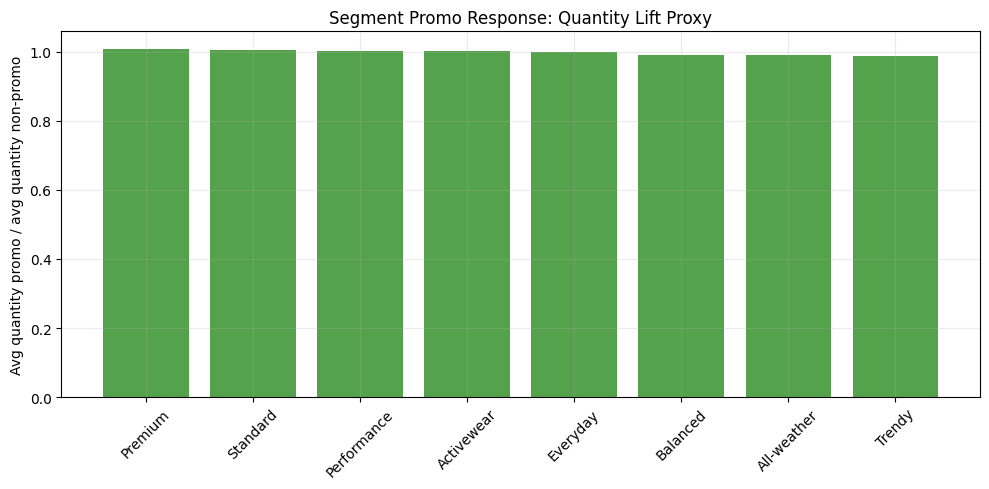

In [12]:
segment_response = pd.DataFrame()
if 'analysis' not in globals() or analysis.empty or 'segment' not in analysis.columns or analysis['segment'].dropna().empty:
    print('Segment data is unavailable; segment response analysis is skipped.')
else:
    seg_status = analysis.dropna(subset=['segment']).groupby(['segment', 'promo_status']).agg(
        lines=('_row_id', 'count'),
        quantity=('quantity', 'sum'),
        revenue=('revenue', 'sum'),
        avg_quantity=('quantity', 'mean'),
        avg_revenue=('revenue', 'mean'),
        gross_profit=('gross_profit', 'sum'),
    ).reset_index()
    seg_pivot = seg_status.pivot(index='segment', columns='promo_status')
    seg_pivot.columns = [f'{str(status).lower().replace("-", "")}_{metric}' for metric, status in seg_pivot.columns]
    segment_response = seg_pivot.reset_index().fillna(0)
    for col in ['promo_lines', 'nonpromo_lines', 'promo_quantity', 'nonpromo_quantity', 'promo_revenue', 'nonpromo_revenue', 'promo_avg_quantity', 'nonpromo_avg_quantity', 'promo_avg_revenue', 'nonpromo_avg_revenue', 'promo_gross_profit', 'nonpromo_gross_profit']:
        if col not in segment_response.columns:
            segment_response[col] = 0.0
    segment_response['total_lines'] = segment_response['promo_lines'] + segment_response['nonpromo_lines']
    segment_response['promo_usage_rate'] = segment_response['promo_lines'] / segment_response['total_lines'].replace(0, np.nan)
    segment_response['quantity_lift_proxy'] = segment_response['promo_avg_quantity'] / segment_response['nonpromo_avg_quantity'].replace(0, np.nan)
    segment_response['revenue_lift_proxy'] = segment_response['promo_avg_revenue'] / segment_response['nonpromo_avg_revenue'].replace(0, np.nan)
    if margin_available:
        segment_response['promo_gross_margin_ratio'] = segment_response['promo_gross_profit'] / segment_response['promo_revenue'].replace(0, np.nan)
        segment_response['nonpromo_gross_margin_ratio'] = segment_response['nonpromo_gross_profit'] / segment_response['nonpromo_revenue'].replace(0, np.nan)
        segment_response['margin_gap_promo_minus_nonpromo'] = segment_response['promo_gross_margin_ratio'] - segment_response['nonpromo_gross_margin_ratio']
    display(segment_response.sort_values('quantity_lift_proxy', ascending=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_seg = segment_response.sort_values('quantity_lift_proxy', ascending=False).head(12)
    ax.bar(plot_seg['segment'].astype(str), plot_seg['quantity_lift_proxy'], color='#54A24B')
    ax.set_title('Segment Promo Response: Quantity Lift Proxy')
    ax.set_ylabel('Avg quantity promo / avg quantity non-promo')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 13. Promotion Type Comparison

When promotion type metadata is available, compare promo item lines across type groups.

,promo_type,promo_lines,quantity,revenue,avg_quantity,avg_revenue,average_discount,gross_profit,gross_margin_ratio
1,percentage,255366,1147508,"5,058,963,791.3300",4.4936,"19,810.6396","2,916.9144","302,541,422.1555",0.0598
0,fixed,20950,94531,"376,473,741.3000",4.5122,"17,970.1070",225.6110,"-230,530,741.3288",-0.6123


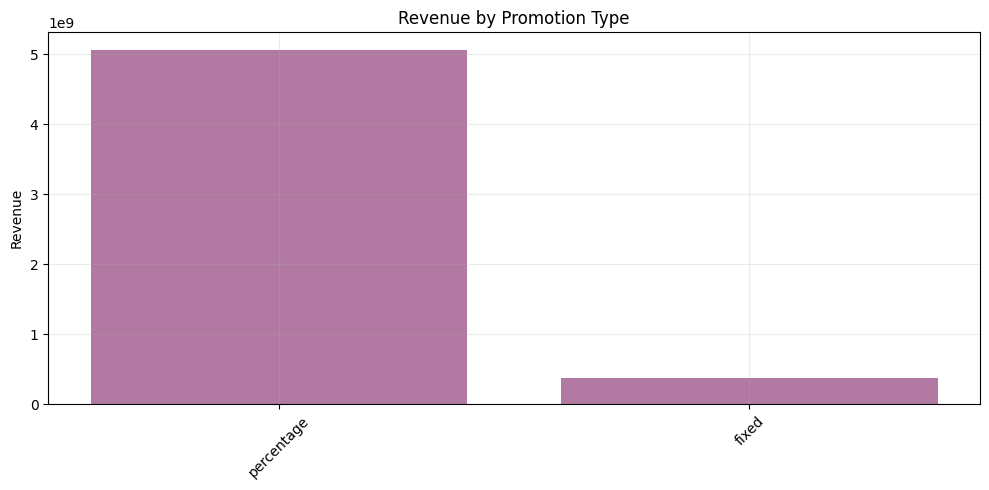

In [13]:
promo_type_summary = pd.DataFrame()
if 'analysis' not in globals() or analysis.empty or 'promo_type' not in analysis.columns or analysis['promo_type'].dropna().empty:
    print('Promotion type is unavailable; promotion type comparison is skipped.')
else:
    promo_only = analysis.loc[analysis['promo_used']].copy()
    if promo_only.empty:
        print('No promo item lines detected; promotion type comparison is skipped.')
    else:
        promo_type_summary = promo_only.groupby('promo_type').agg(
            promo_lines=('_row_id', 'count'),
            quantity=('quantity', 'sum'),
            revenue=('revenue', 'sum'),
            avg_quantity=('quantity', 'mean'),
            avg_revenue=('revenue', 'mean'),
            average_discount=('discount_amount', 'mean'),
            gross_profit=('gross_profit', 'sum'),
        ).reset_index().sort_values('revenue', ascending=False)
        if 'discount_rate' in promo_only.columns and promo_only['discount_rate'].notna().any():
            promo_type_summary = promo_type_summary.merge(promo_only.groupby('promo_type')['discount_rate'].mean().rename('average_discount_rate').reset_index(), on='promo_type', how='left')
        if margin_available:
            promo_type_summary['gross_margin_ratio'] = promo_type_summary['gross_profit'] / promo_type_summary['revenue'].replace(0, np.nan)
        display(promo_type_summary)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(promo_type_summary['promo_type'].astype(str), promo_type_summary['revenue'], color='#B279A2')
        ax.set_title('Revenue by Promotion Type')
        ax.set_ylabel('Revenue')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

## 14. Promo Effect and Revenue Decomposition

Decompose daily revenue into promo and non-promo components. Top revenue days are shown with promo revenue share, quantity, and average revenue per unit context.

,date,total_revenue,promo_revenue,nonpromo_revenue,promo_revenue_share,total_quantity,promo_quantity_share,average_revenue_per_unit,gross_margin_ratio
2156,2018-05-30,"20,905,271.3500",0.0000,"20,905,271.3500",0.0000,"3,879.0000",0.0000,"5,389.3455",0.2090
2157,2018-05-31,"19,289,944.1200",0.0000,"19,289,944.1200",0.0000,"3,700.0000",0.0000,"5,213.4984",0.1933
2158,2018-06-01,"19,245,165.7800",0.0000,"19,245,165.7800",0.0000,"3,466.0000",0.0000,"5,552.5579",0.2056
1793,2017-06-01,"17,639,270.8800",0.0000,"17,639,270.8800",0.0000,"3,218.0000",0.0000,"5,481.4391",0.2005
2159,2018-06-02,"17,529,108.3400",0.0000,"17,529,108.3400",0.0000,"3,193.0000",0.0000,"5,489.8554",0.2180
1794,2017-06-02,"17,528,852.8800",0.0000,"17,528,852.8800",0.0000,"3,167.0000",0.0000,"5,534.8446",0.1925
1730,2017-03-30,"17,516,038.8200","17,516,038.8200",0.0000,1.0000,"3,435.0000",1.0000,"5,099.2835",0.0737
1394,2016-04-28,"17,388,183.1900",0.0000,"17,388,183.1900",0.0000,"3,231.0000",0.0000,"5,381.6723",0.1961
664,2014-04-29,"17,347,427.2700",0.0000,"17,347,427.2700",0.0000,"3,503.0000",0.0000,"4,952.1631",0.2073
1792,2017-05-31,"17,314,841.8600",0.0000,"17,314,841.8600",0.0000,"3,245.0000",0.0000,"5,335.8527",0.2003


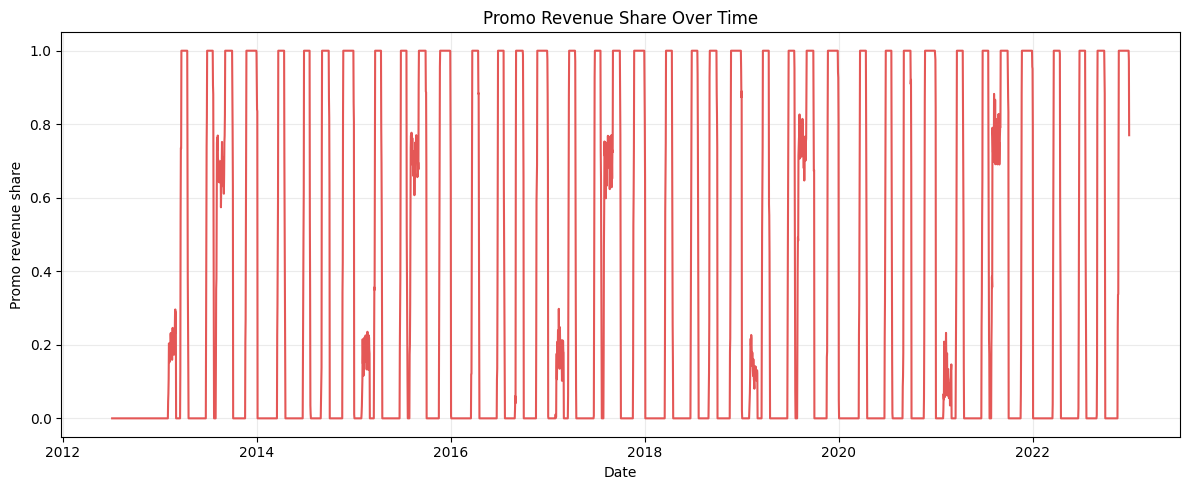

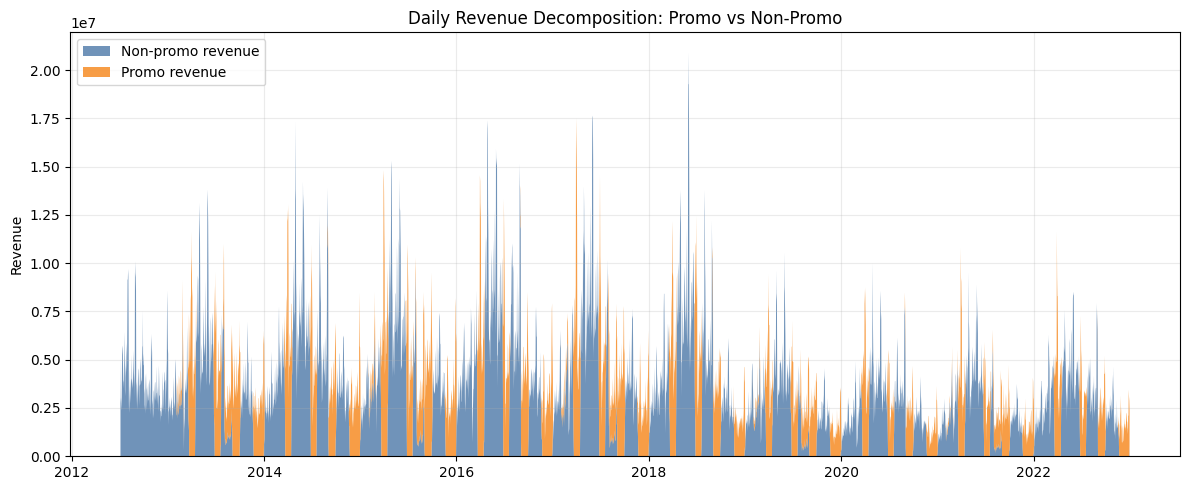

In [14]:
if 'daily' not in globals() or daily.empty:
    print('Daily dataset is unavailable; revenue decomposition cannot be computed.')
else:
    decomp = daily.copy().sort_values('date')
    decomp['average_revenue_per_unit'] = decomp['total_revenue'] / decomp['total_quantity'].replace(0, np.nan)
    top_cols = ['date', 'total_revenue', 'promo_revenue', 'nonpromo_revenue', 'promo_revenue_share', 'total_quantity', 'promo_quantity_share', 'average_revenue_per_unit']
    if 'gross_margin_ratio' in decomp.columns:
        top_cols.append('gross_margin_ratio')
    display(decomp.sort_values('total_revenue', ascending=False).head(20)[top_cols])

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(decomp['date'], decomp['promo_revenue_share'], color='#E45756')
    ax.set_title('Promo Revenue Share Over Time')
    ax.set_ylabel('Promo revenue share')
    ax.set_xlabel('Date')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stackplot(decomp['date'], decomp['nonpromo_revenue'], decomp['promo_revenue'], labels=['Non-promo revenue', 'Promo revenue'], colors=['#4C78A8', '#F58518'], alpha=0.8)
    ax.set_title('Daily Revenue Decomposition: Promo vs Non-Promo')
    ax.set_ylabel('Revenue')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

## 15. Forecast and Explainability Feature Preview

Build a daily preview of promotion-related features. Calendar-known features are valid for a forecast/test period only when the future promotion calendar is known and allowed. If future promotion information is unknown, use lagged or historical promotion features only. Lag and rolling features below are shifted before rolling to avoid same-day leakage.

In [15]:
feature_preview = pd.DataFrame()
calendar_feature_cols = []
historical_feature_cols = []

if 'daily' not in globals() or daily.empty:
    print('Daily dataset is unavailable; forecast feature preview cannot be built.')
else:
    feature_preview = daily.sort_values('date').copy()
    if 'analysis' in globals() and 'discount_amount' in analysis.columns:
        feature_preview['avg_discount_value'] = analysis.dropna(subset=['date']).groupby('date')['discount_amount'].mean().reindex(feature_preview['date']).values
    if 'discount_rate' in analysis.columns and analysis['discount_rate'].notna().any():
        feature_preview['avg_discount_rate'] = analysis.dropna(subset=['date']).groupby('date')['discount_rate'].mean().reindex(feature_preview['date']).values
    calendar_feature_cols += ['promo_revenue_share', 'promo_quantity_share', 'promo_line_ratio', 'avg_discount_value']
    if 'avg_discount_rate' in feature_preview.columns:
        calendar_feature_cols.append('avg_discount_rate')

    if promotions is not None and cols.get('promo_start') and cols.get('promo_end'):
        cal = promotions.copy()
        cal['_start'] = pd.to_datetime(cal[cols['promo_start']], errors='coerce').dt.floor('D')
        cal['_end'] = pd.to_datetime(cal[cols['promo_end']], errors='coerce').dt.floor('D')
        if cal[['_start', '_end']].notna().all(axis=1).any():
            active_counts, percentage_counts, fixed_counts = [], [], []
            for d in feature_preview['date']:
                active = cal[(cal['_start'].notna()) & (cal['_end'].notna()) & (cal['_start'] <= d) & (cal['_end'] >= d)]
                active_counts.append(len(active))
                if cols.get('promo_type'):
                    t = active[cols['promo_type']].astype('string').str.lower()
                    percentage_counts.append(t.str.contains('percent|percentage|pct', na=False).sum())
                    fixed_counts.append(t.str.contains('fixed|amount|value|cash', na=False).sum())
                else:
                    percentage_counts.append(np.nan)
                    fixed_counts.append(np.nan)
            feature_preview['active_promo_count'] = active_counts
            feature_preview['percentage_promo_count'] = percentage_counts
            feature_preview['fixed_promo_count'] = fixed_counts
            calendar_feature_cols += ['active_promo_count', 'percentage_promo_count', 'fixed_promo_count']
    else:
        print('Promotion start/end dates unavailable; active promo calendar counts are skipped.')

    if 'promo_gross_margin_ratio' in feature_preview.columns:
        calendar_feature_cols.append('promo_gross_margin_ratio')
    if 'nonpromo_gross_margin_ratio' in feature_preview.columns:
        calendar_feature_cols.append('nonpromo_gross_margin_ratio')

    intensity = feature_preview['promo_line_ratio'].fillna(0)
    feature_preview['promo_intensity_lag_1'] = intensity.shift(1)
    feature_preview['promo_intensity_lag_7'] = intensity.shift(7)
    feature_preview['promo_intensity_roll_mean_30'] = intensity.shift(1).rolling(30, min_periods=7).mean()
    historical_feature_cols += ['promo_intensity_lag_1', 'promo_intensity_lag_7', 'promo_intensity_roll_mean_30']

    preview_cols = ['date', 'total_revenue', 'total_quantity', 'promo_revenue_share', 'promo_quantity_share', 'promo_line_ratio']
    for c in ['active_promo_count', 'avg_discount_value', 'avg_discount_rate', 'percentage_promo_count', 'fixed_promo_count', 'promo_gross_margin_ratio', 'nonpromo_gross_margin_ratio', 'promo_intensity_lag_1', 'promo_intensity_lag_7', 'promo_intensity_roll_mean_30']:
        if c in feature_preview.columns:
            preview_cols.append(c)
    display(feature_preview[preview_cols].head(20))
    display(pd.DataFrame({
        'feature': calendar_feature_cols + historical_feature_cols,
        'feature_type': ['calendar-known or same-day observed'] * len(calendar_feature_cols) + ['historical lag/rolling'] * len(historical_feature_cols),
        'forecast_use_note': ['Use for test/forecast only if future promo calendar/status is known and allowed.'] * len(calendar_feature_cols) + ['Can be used without future promo knowledge because values use shifted history.'] * len(historical_feature_cols),
    }))

,date,total_revenue,total_quantity,promo_revenue_share,promo_quantity_share,promo_line_ratio,active_promo_count,avg_discount_value,percentage_promo_count,fixed_promo_count,promo_gross_margin_ratio,nonpromo_gross_margin_ratio,promo_intensity_lag_1,promo_intensity_lag_7,promo_intensity_roll_mean_30
0,2012-07-04,"5,123,547.9400",777.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2226,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",428.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2185,0.0000,NaN,NaN
2,2012-07-06,"3,054,029.4200",441.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.1756,0.0000,NaN,NaN
3,2012-07-07,"2,667,930.9400",364.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2098,0.0000,NaN,NaN
4,2012-07-08,"2,360,851.9000",394.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2339,0.0000,NaN,NaN
5,2012-07-09,"3,548,386.4600",730.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2143,0.0000,NaN,NaN
6,2012-07-10,"5,234,938.6200",928.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2274,0.0000,NaN,NaN
7,2012-07-11,"5,582,884.7800","1,097.0000",0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2229,0.0000,0.0000,0.0000
8,2012-07-12,"5,734,632.0200","1,241.0000",0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2225,0.0000,0.0000,0.0000
9,2012-07-13,"5,309,511.7100",995.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,NaN,0.2196,0.0000,0.0000,0.0000


,feature,feature_type,forecast_use_note
0,promo_revenue_share,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
1,promo_quantity_share,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
2,promo_line_ratio,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
3,avg_discount_value,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
4,active_promo_count,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
5,percentage_promo_count,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
6,fixed_promo_count,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
7,promo_gross_margin_ratio,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
8,nonpromo_gross_margin_ratio,calendar-known or same-day observed,Use for test/forecast only if future promo cal...
9,promo_intensity_lag_1,historical lag/rolling,Can be used without future promo knowledge bec...


## 16. Key Observations and Warnings

Final concise summary. The language remains observational: promo lines/days show associations, not proven causal effects.

In [16]:
def fmt_money(x):
    return 'n/a' if pd.isna(x) else f'{x:,.2f}'
def fmt_pct(x):
    return 'n/a' if pd.isna(x) else f'{x:.2%}'
def fmt_num(x):
    return 'n/a' if pd.isna(x) else f'{x:,.4f}'

summary_lines = []
if 'analysis' not in globals() or analysis.empty:
    summary_lines.append('Item-level analysis dataset could not be built, so promotion effect EDA is incomplete.')
else:
    if 'summary' in globals() and not summary.empty and set(summary['promo_status']) >= {'Promo', 'Non-promo'}:
        sidx = summary.set_index('promo_status')
        summary_lines.append(f"Promo item lines show average item revenue of {fmt_money(sidx.loc['Promo', 'average_item_revenue'])} versus {fmt_money(sidx.loc['Non-promo', 'average_item_revenue'])} for non-promo lines.")
        summary_lines.append(f"Promo item lines show average quantity per line of {fmt_num(sidx.loc['Promo', 'average_quantity_per_line'])} versus {fmt_num(sidx.loc['Non-promo', 'average_quantity_per_line'])} for non-promo lines.")
        if 'gross_margin_ratio' in sidx.columns and pd.notna(sidx.loc['Promo', 'gross_margin_ratio']):
            summary_lines.append(f"Weighted gross margin ratio is {fmt_pct(sidx.loc['Promo', 'gross_margin_ratio'])} for promo lines versus {fmt_pct(sidx.loc['Non-promo', 'gross_margin_ratio'])} for non-promo lines.")
        else:
            summary_lines.append('Gross margin could not be fully evaluated because margin or cost data is missing.')
    else:
        summary_lines.append('Promo vs non-promo line comparison could not be fully computed, likely because one status group is missing.')

    if 'daily_compare' in globals() and not daily_compare.empty:
        didx = daily_compare.set_index('promo_active_day')
        if True in didx.index and False in didx.index:
            summary_lines.append(f"Promo-active days are associated with average daily revenue of {fmt_money(didx.loc[True, 'average_daily_revenue'])} versus {fmt_money(didx.loc[False, 'average_daily_revenue'])} on non-promo days.")
            summary_lines.append(f"Promo-active days are associated with average daily quantity of {fmt_num(didx.loc[True, 'average_daily_quantity'])} versus {fmt_num(didx.loc[False, 'average_daily_quantity'])} on non-promo days.")

    if 'category_response' in globals() and not category_response.empty:
        valid_cat = category_response.replace([np.inf, -np.inf], np.nan).dropna(subset=['quantity_lift_proxy'])
        if not valid_cat.empty:
            top_qty_cats = valid_cat.sort_values(['quantity_lift_proxy', 'promo_quantity'], ascending=False).head(5)['category'].astype(str).tolist()
            top_rev_cats = valid_cat.replace([np.inf, -np.inf], np.nan).dropna(subset=['revenue_lift_proxy']).sort_values(['revenue_lift_proxy', 'promo_revenue'], ascending=False).head(5)['category'].astype(str).tolist()
            summary_lines.append('Categories with strongest promo-associated quantity lift proxy: ' + ', '.join(top_qty_cats))
            summary_lines.append('Categories with strongest promo-associated revenue lift proxy: ' + ', '.join(top_rev_cats))
            if margin_available and 'margin_gap_promo_minus_nonpromo' in valid_cat.columns:
                weak = valid_cat[(valid_cat['quantity_lift_proxy'] > 1) & (valid_cat['margin_gap_promo_minus_nonpromo'] < 0)].sort_values(['quantity_lift_proxy', 'margin_gap_promo_minus_nonpromo'], ascending=[False, True]).head(5)
                if not weak.empty:
                    summary_lines.append('Categories with higher promo-associated quantity but weaker margin: ' + ', '.join(weak['category'].astype(str).tolist()))
                else:
                    summary_lines.append('No category clearly shows both higher promo-associated quantity and weaker promo margin under the current thresholds.')

    if 'promo_type_summary' in globals() and not promo_type_summary.empty:
        summary_lines.append('Promotion types associated with the highest observed promo quantity: ' + ', '.join(promo_type_summary.sort_values('quantity', ascending=False).head(3)['promo_type'].astype(str).tolist()))
        summary_lines.append('Promotion types associated with the highest observed promo revenue: ' + ', '.join(promo_type_summary.sort_values('revenue', ascending=False).head(3)['promo_type'].astype(str).tolist()))

    if 'quality_summary' in globals() and not quality_summary.empty:
        nonzero_quality = quality_summary[quality_summary['count'] > 0]
        if not nonzero_quality.empty:
            warning_text = '; '.join(nonzero_quality.head(8).assign(txt=lambda d: d['check'] + '=' + d['count'].astype(str))['txt'].tolist())
            summary_lines.append('Data quality warning counts: ' + warning_text)
        else:
            summary_lines.append('No major nonzero promo, discount, revenue, quantity, or margin quality warnings were detected by the configured checks.')

summary_lines.append('Recommended promotion features for forecasting and explainability: promo revenue/share features, promo line ratio, discount intensity, active promo calendar counts and promotion type counts when calendar-known, category/segment promo response features, and shifted lag/rolling promo intensity features.')
summary_lines.append('Forecasting caution: use future promo calendar/status features only if the promotion calendar is known and allowed for the test/forecast period. If future promotion activity is unknown, use only lagged/historical promo patterns or separately forecasted promotion activity.')
summary_lines.append('Causal caution: this is observational EDA, not a causal experiment; seasonality, campaign targeting, traffic, product mix, stock availability, and other confounders may explain observed differences.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Promo item lines show average item revenue of 19,671.09 versus 25,082.61 for non-promo lines.
- Promo item lines show average quantity per line of 4.4950 versus 4.4966 for non-promo lines.
- Weighted gross margin ratio is 1.32% for promo lines versus 19.96% for non-promo lines.
- Promo-active days are associated with average daily revenue of 3,990,789.21 versus 4,524,082.51 on non-promo days.
- Promo-active days are associated with average daily quantity of 878.1113 versus 806.3062 on non-promo days.
- Categories with strongest promo-associated quantity lift proxy: Outdoor, Streetwear, Casual, GenZ
- Categories with strongest promo-associated revenue lift proxy: Casual, GenZ, Streetwear, Outdoor
- Categories with higher promo-associated quantity but weaker margin: Outdoor
- Promotion types associated with the highest observed promo quantity: percentage, fixed
- Promotion types associated with the highest observed promo revenue: percentage, fixed
- Data q